### Chatbot Reading Existing Memories in Store

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

e:\LangGraph\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Sahil"})
store.put(user_details, "profile_2", {"data": "Profession: Student in Panjab University"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building Agentic AI (Python-based project)"})

In [3]:
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}"""

In [4]:
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------
llm = ChatGroq(model = 'llama-3.3-70b-versatile')

In [ ]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format( #create dynamic string by putting value in placeholder
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

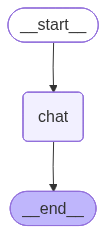

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph


In [7]:
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Hi Sahil, I'd be happy to explain Gen AI in simple terms. Gen AI, or General Artificial Intelligence, refers to a type of AI that can perform any intellectual task that a human can. It's like a super-smart computer that can learn, reason, and apply knowledge across various domains, much like a human.

Think of it like your Agentic AI project, but instead of focusing on a specific task, Gen AI aims to be a general-purpose problem solver. For example, in Python, you might use a library like `transformers` to build a model that can understand and respond to natural language inputs, but a Gen AI system would be able to go beyond that and apply its knowledge to solve complex problems in multiple areas.

Here's a simple Python example to illustrate this concept:
```python
import random

def gen_ai_example():
    # Simulate a Gen AI system that can learn and apply knowledge
    knowledge_base = {
        "math": lambda x, y: x + y,
        "language": lambda x: x.upper()
    }

    task = ran

### Merged Workflow

In [1]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

e:\LangGraph\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
store= InMemoryStore()

In [3]:
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
# 3) Memory extraction LLM
memory_llm = ChatGroq(model = 'llama-3.3-70b-versatile')

In [5]:
class memoryitem(BaseModel):
    text:str = Field(description='Atomic user memory')
    is_new:bool = Field(description='True if new, false if duplicate')

In [6]:
class memorydecision(BaseModel):
    should_write:bool
    memories:List[memoryitem]=Field(default_factory=list)

In [8]:
memory_extractor = memory_llm.with_structured_output(memorydecision)

In [9]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list."""

In [10]:
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: memorydecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [11]:
# 5) Node 2: chat
# ----------------------------
chat_llm =ChatGroq(model = 'llama-3.3-70b-versatile')

In [12]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

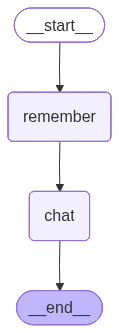

In [13]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [14]:
#  Demo
config = {"configurable": {"user_id": "u1"}}
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Sahil"}]}, config)
result['messages'][-1].content

"Hello Sahil, it's nice to meet you. I'll be happy to help you with any questions or topics you'd like to discuss. I've taken note that your name is Sahil, and I'll make sure to address you personally in our conversation. \n\nSince we're just starting out, I'd love to learn more about your interests and what brings you here today. Are you working on a specific project, or do you have a particular topic in mind that you'd like to explore?\n\nHere are a few questions to consider for our next steps:\n1. What are your favorite hobbies or interests, Sahil?\n2. Are you currently working on any projects or assignments that you'd like some help with?\n3. Is there a specific subject or topic you're curious about and would like to learn more about?"

In [15]:
result = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on YouTube"}]}, config)
print(result['messages'][-1].content)

Hi Sahil, it's great to hear that you're sharing your knowledge of AI with the world through YouTube. Teaching AI can be a rewarding experience, and having a platform like YouTube to reach a wide audience is fantastic. What specific areas of AI do you focus on in your teachings, such as machine learning, deep learning, or natural language processing? 

I'd love to learn more about your content and see if there's anything I can help you with, whether it's suggestions for new topics or ideas for engaging your audience.

Here are three questions to consider for our next steps:
1. What tools or programming languages do you use most often in your AI lessons, Sahil?
2. Have you explored any specific AI applications or projects that you'd like to feature in your YouTube content?
3. How do you approach making complex AI concepts accessible to a broad audience, and are there any particular techniques that have worked well for you?


In [16]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hi Sahil, I know you're passionate about teaching AI concepts on your YouTube channel. GenAI, or General Artificial Intelligence, refers to a type of AI that can perform any intellectual task that a human can. It's essentially a machine that can learn, reason, and apply knowledge across a wide range of tasks, much like a human.

Think of it like this: currently, most AI systems are designed to excel in specific areas, like playing chess or recognizing images. GenAI, on the other hand, aims to create a more general-purpose AI that can adapt to various tasks, from solving complex problems to creating art.

As someone who teaches AI, you might find it interesting to explore how GenAI can be applied in educational settings, such as personalized learning platforms or intelligent tutoring systems.

Here are three further questions that might interest you, Sahil:
1. How do you think GenAI could be used to create more interactive and engaging AI tutorials for your YouTube audience?
2. What are

In [17]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

My name is Sahil
I teach AI on YouTube
